# Cell 1 – Import Libraries
Load all necessary Python libraries for data handling (pandas, numpy), visualization (matplotlib, seaborn), regression models (scikit-learn), time-series statistics (statsmodels), and pipeline creation. Suppress warnings to keep output clean.

**Concepts:** Supervised Learning, Bias-Variance Tradeoff, Overfitting/Underfitting, Data Cleaning, EDA, Encoding, Scaling, Pipelines, Cross-Validation, Time Series Forecasting, Stationarity.

In [1]:
# ========================
# Cell 1 - Import Libraries
# ========================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# Modeling
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Time Series & Statistics
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose

import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully.")

Libraries imported successfully.


# Cell 2 – Load Dataset
Upload the Tesla CSV file from the local machine and read it into a pandas DataFrame. Display the shape and first five rows to verify correct loading and column names.

**Concepts:** Data Ingestion, Initial Inspection.

In [2]:
# Cell 2 - Load data

df = pd.read_csv('tesla_deliveries_dataset_2015_2025.csv')   #
df.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


# Cell 3 – Data Cleaning & Initial Inspection
Combine `Year` and `Month` into a proper datetime column for chronological operations. Sort the data by date, reset index, and inspect for missing values, duplicate rows, and data types. Print basic statistics of numeric columns and list the unique values of categorical features to understand the dataset structure.

**Concepts:** Data Cleaning (missing values, duplicates), EDA (data types, distributions, categories), Time-Series Preparation.

In [3]:
# ========================================
# Cell 3 - Data Cleaning & Initial Inspection
# ========================================

# 1. Create a proper Date column from Year and Month
df['Date'] = pd.to_datetime(df['Year'].astype(str) + '-' + df['Month'].astype(str) + '-01')

# 2. Sort chronologically
df.sort_values('Date', inplace=True)
df.reset_index(drop=True, inplace=True)

# 3. Check data types and missing values
print("=== Data Types ===")
print(df.dtypes)

print("\n=== Missing Values ===")
print(df.isnull().sum())

print("\n=== Duplicated Rows ===")
print(f"Number of duplicated rows: {df.duplicated().sum()}")

# 4. Basic statistics of numeric columns
print("\n=== Numeric Summary (Target: Estimated_Deliveries) ===")
print(df[['Estimated_Deliveries', 'Production_Units', 'Avg_Price_USD',
          'Battery_Capacity_kWh', 'Range_km', 'CO2_Saved_tons']].describe())

# 5. Check unique categories
print("\n=== Unique Categories ===")
print("Regions:", df['Region'].unique())
print("Models:", df['Model'].unique())
print("Source Types:", df['Source_Type'].unique())

# 6. Final shape
print(f"\nFinal shape after cleaning: {df.shape}")

=== Data Types ===
Year                             int64
Month                            int64
Region                          object
Model                           object
Estimated_Deliveries             int64
Production_Units                 int64
Avg_Price_USD                  float64
Battery_Capacity_kWh             int64
Range_km                         int64
CO2_Saved_tons                 float64
Source_Type                     object
Charging_Stations                int64
Date                    datetime64[ns]
dtype: object

=== Missing Values ===
Year                    0
Month                   0
Region                  0
Model                   0
Estimated_Deliveries    0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Source_Type             0
Charging_Stations       0
Date                    0
dtype: int64

=== Duplicated Rows ===
Number of duplicated rows: 0

=== Numeric Summary (Target: E

# Cell 4 – EDA

- **Target histogram** → check skewness, range.
- **Global monthly sum line plot** → trend, seasonality, growth.
- **Boxplots** → compare delivery distributions across regions & models.
- **Correlation heatmap** → identify relationships between numerical features & target; spot multicollinearity.
- **ADF test** → test stationarity of global monthly deliveries (important for time series).

Covers: EDA, visualisation, correlation analysis, stationarity (time series component).

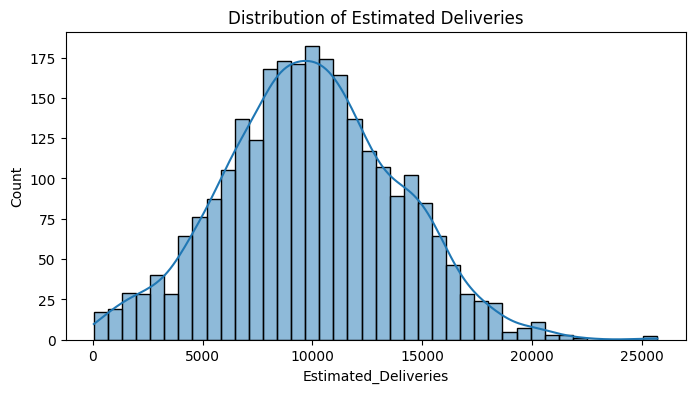

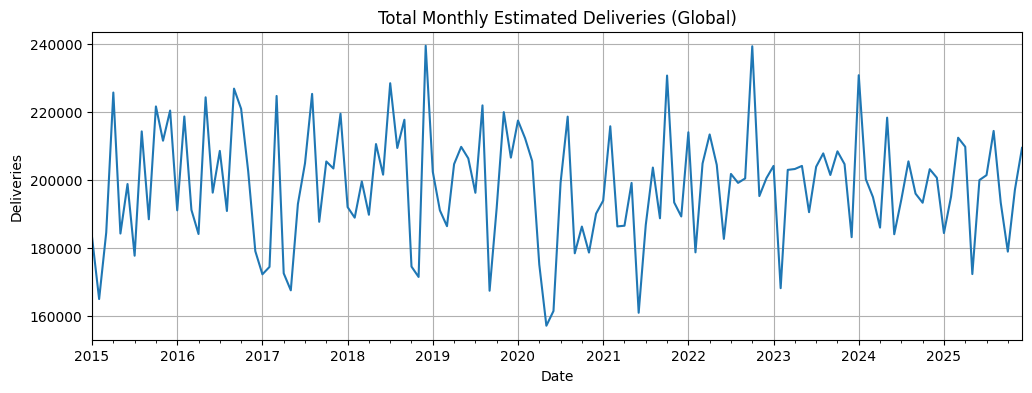

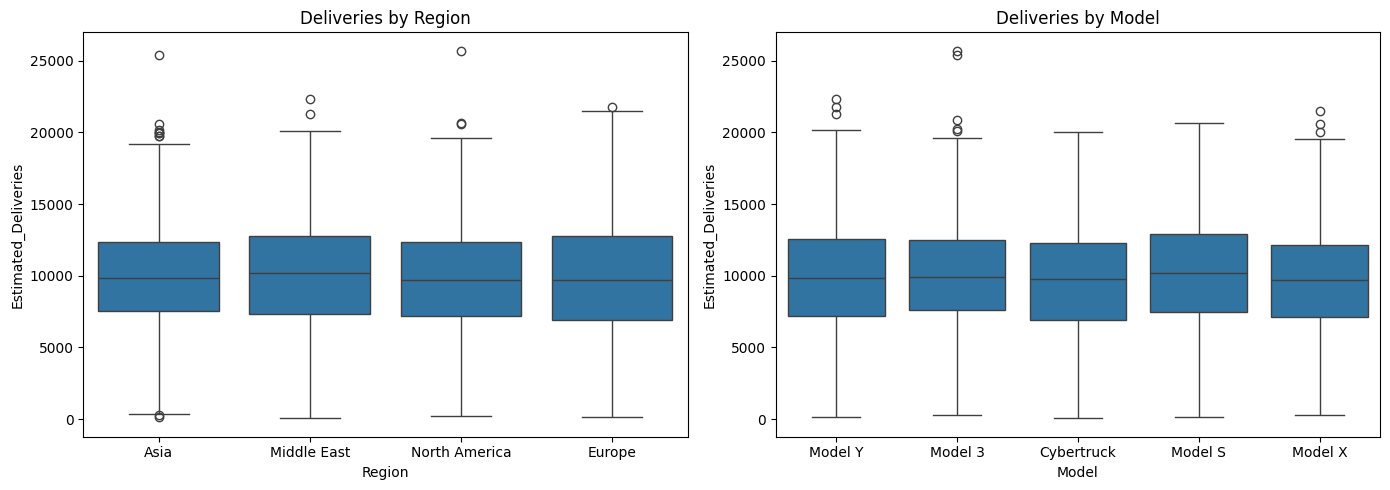

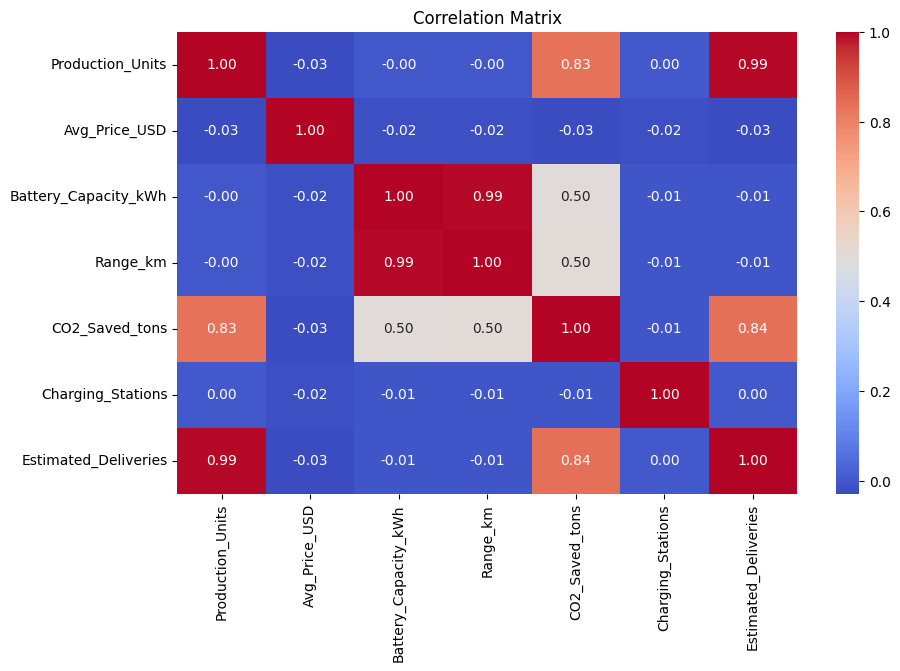

ADF Statistic: -8.881
p-value: 0.0
Conclusion: Series is stationary.


In [4]:
# ===================================================
# Cell 4 - Exploratory Data Analysis (EDA)
# ===================================================

target = 'Estimated_Deliveries'

# 1. Target distribution
plt.figure(figsize=(8,4))
sns.histplot(df[target], kde=True, bins=40)
plt.title('Distribution of Estimated Deliveries')
plt.xlabel(target)
plt.show()

# 2. Global monthly deliveries over time
ts_global = df.groupby('Date')[target].sum()
plt.figure(figsize=(12,4))
ts_global.plot()
plt.title('Total Monthly Estimated Deliveries (Global)')
plt.ylabel('Deliveries')
plt.grid(True)
plt.show()

# 3. Boxplots by Region and Model
fig, axes = plt.subplots(1, 2, figsize=(14,5))
sns.boxplot(x='Region', y=target, data=df, ax=axes[0])
axes[0].set_title('Deliveries by Region')
sns.boxplot(x='Model', y=target, data=df, ax=axes[1])
axes[1].set_title('Deliveries by Model')
plt.tight_layout()
plt.show()

# 4. Correlation heatmap
num_cols = ['Production_Units', 'Avg_Price_USD', 'Battery_Capacity_kWh',
            'Range_km', 'CO2_Saved_tons', 'Charging_Stations']
plt.figure(figsize=(10,6))
sns.heatmap(df[num_cols + [target]].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

# 5. Stationarity check (ADF test) on global monthly total
adf_result = adfuller(ts_global.dropna())
print('ADF Statistic:', round(adf_result[0], 4))
print('p-value:', round(adf_result[1], 4))
if adf_result[1] > 0.05:
    print("Conclusion: Series is NON-stationary (p > 0.05) – differencing or trend removal may be needed.")
else:
    print("Conclusion: Series is stationary.")

# Cell 5 – Handling Missing Values & Duplicates

- Checks missing values and duplicates (data is clean).  
- Demonstrates **how** we would handle them:  
  - Drop rows with missing target.  
  - Impute numeric features with median, categorical with mode.  
  - Drop duplicate rows.  
- Confirms data types and final shape.

**ML Concepts:** Data Cleaning (missing value imputation, duplicate removal) — essential preprocessing step.

In [5]:
# ===============================================================
# Cell 5 - Missing Values & Duplicates Check
# ===============================================================

# Check for missing values
missing = df.isnull().sum()
print("Missing values per column:\n", missing)

# Handle missing values if any exist (none in this dataset)
if missing.any():
    # Drop rows with missing target
    df.dropna(subset=['Estimated_Deliveries'], inplace=True)
    # Impute numeric columns with median
    num_cols = df.select_dtypes(include=[np.number]).columns
    df[num_cols] = df[num_cols].fillna(df[num_cols].median())
    # Impute categorical columns with mode
    cat_cols = df.select_dtypes(include=['object']).columns
    df[cat_cols] = df[cat_cols].fillna(df[cat_cols].mode().iloc[0])
    print("Missing values handled.")
else:
    print("✅ No missing values found.")

# Check and handle duplicate rows
duplicates = df.duplicated().sum()
print(f"Duplicate rows found: {duplicates}")
if duplicates > 0:
    df.drop_duplicates(inplace=True)
    print("Duplicates removed.")
else:
    print("✅ No duplicates found.")

# Confirm data types and shape
print("\nData types (key columns):")
print(df.dtypes[['Date', 'Estimated_Deliveries', 'Avg_Price_USD']])
print(f"Shape: {df.shape}")

Missing values per column:
 Year                    0
Month                   0
Region                  0
Model                   0
Estimated_Deliveries    0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Source_Type             0
Charging_Stations       0
Date                    0
dtype: int64
✅ No missing values found.
Duplicate rows found: 0
✅ No duplicates found.

Data types (key columns):
Date                    datetime64[ns]
Estimated_Deliveries             int64
Avg_Price_USD                  float64
dtype: object
Shape: (2640, 13)


# Cell 6 – Encoding Categorical Variables

- Selects categorical columns: `Region`, `Model`, `Source_Type`.  
- Uses `pd.get_dummies` with `drop_first=True` to create binary dummy columns.  
- `drop_first` avoids the dummy variable trap (redundant category).  
- Expands the dataset from 13 columns to more (3 regions→3 dummies, 5 models→4 dummies, 3 source types→2 dummies).  

**ML Concepts:** Encoding Techniques (One-Hot Encoding) – necessary for linear models that require numeric input.

In [6]:
# ==============================================
# Cell 6 - Encoding Categorical Features (One-Hot)
# ==============================================

# Identify categorical columns
cat_cols = ['Region', 'Model', 'Source_Type']

# Apply one-hot encoding (drop_first to avoid dummy variable trap)
df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=True)

print("Original shape:", df.shape)
print("New shape after encoding:", df_encoded.shape)

# Check new column names (first few)
print("\nFirst 5 new columns:", df_encoded.columns.tolist()[:5])
print("Last 5 new columns:", df_encoded.columns.tolist()[-5:])

# Preview encoded data
df_encoded.head()

Original shape: (2640, 13)
New shape after encoding: (2640, 19)

First 5 new columns: ['Year', 'Month', 'Estimated_Deliveries', 'Production_Units', 'Avg_Price_USD']
Last 5 new columns: ['Model_Model S', 'Model_Model X', 'Model_Model Y', 'Source_Type_Interpolated (Month)', 'Source_Type_Official (Quarter)']


,Year,Month,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations,Date,Region_Europe,Region_Middle East,Region_North America,Model_Model 3,Model_Model S,Model_Model X,Model_Model Y,Source_Type_Interpolated (Month),Source_Type_Official (Quarter)
0,2015,1,12446,13885,55183.13,60,340,634.75,4390,2015-01-01,False,False,False,False,False,False,True,False,True
1,2015,1,11446,12752,89289.40,100,588,1009.54,8925,2015-01-01,False,True,False,True,False,False,False,False,False
2,2015,1,8803,9344,102888.58,60,336,443.67,3923,2015-01-01,False,True,False,False,False,False,False,True,False
3,2015,1,6367,6802,104962.32,82,459,438.37,9170,2015-01-01,False,False,True,False,False,False,False,False,False
4,2015,1,8795,9165,87988.73,82,456,601.58,12626,2015-01-01,False,False,False,True,False,False,False,False,True


# Cell 7 – Feature Engineering (Time‑Series Features)

- Copies original `df` to keep `Region`/`Model` for grouping.
- Creates **lag features** (t-1, t-2, t-3) inside each Region-Model group to avoid mixing different series.
- Creates **rolling mean & std** using only past values (`shift(1).rolling(3)`) → no future leakage.
- Adds `Year`, `Month`, `Quarter` as numerical time indicators.
- Drops rows where lags are NaN (start of each group).

**ML Concepts:**  
Feature Engineering, Lag Features, Rolling Statistics, Time Series Components, Data Leakage prevention.

In [7]:
# ==============================================================
# Cell 7 - Feature Engineering (Lag & Rolling Features)
# ==============================================================


df_feat = df[['Date', 'Region', 'Model', 'Estimated_Deliveries', 'Production_Units',
              'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km', 'CO2_Saved_tons',
              'Charging_Stations']].copy()

# Ensure chronological order within each group
df_feat.sort_values(['Region', 'Model', 'Date'], inplace=True)

# Create lag features (shift by 1,2,3 months) for each region-model group
df_feat['Deliveries_Lag1'] = df_feat.groupby(['Region', 'Model'])['Estimated_Deliveries'].shift(1)
df_feat['Deliveries_Lag2'] = df_feat.groupby(['Region', 'Model'])['Estimated_Deliveries'].shift(2)
df_feat['Deliveries_Lag3'] = df_feat.groupby(['Region', 'Model'])['Estimated_Deliveries'].shift(3)

# Rolling 3-month mean (using past values only, shift(1) then rolling)
df_feat['Deliveries_RollMean3'] = df_feat.groupby(['Region', 'Model'])['Estimated_Deliveries'].transform(
    lambda x: x.shift(1).rolling(3, min_periods=1).mean())

# Rolling 3-month std dev
df_feat['Deliveries_RollStd3'] = df_feat.groupby(['Region', 'Model'])['Estimated_Deliveries'].transform(
    lambda x: x.shift(1).rolling(3, min_periods=1).std())

# Add time components from Date
df_feat['Year'] = df_feat['Date'].dt.year
df_feat['Month'] = df_feat['Date'].dt.month
df_feat['Quarter'] = df_feat['Date'].dt.quarter

# Drop rows with NaN lags (first few months of each group)
df_feat.dropna(inplace=True)

print("Shape after feature engineering:", df_feat.shape)
df_feat.head()

Shape after feature engineering: (2580, 18)


,Date,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations,Deliveries_Lag1,Deliveries_Lag2,Deliveries_Lag3,Deliveries_RollMean3,Deliveries_RollStd3,Year,Month,Quarter
75,2015-04-01,Asia,Cybertruck,15221,15951,112686.63,60,341,778.55,3130,10257.0,13254.0,11325.0,11612.000000,1518.973008,2015,4,2
85,2015-05-01,Asia,Cybertruck,6406,7281,107577.61,75,448,430.48,11708,15221.0,10257.0,13254.0,12910.666667,2499.746454,2015,5,2
110,2015-06-01,Asia,Cybertruck,7201,8144,114461.07,75,414,447.18,6322,6406.0,15221.0,10257.0,10628.000000,4419.195289,2015,6,2
123,2015-07-01,Asia,Cybertruck,113,118,115067.04,120,709,12.02,14580,7201.0,6406.0,15221.0,9609.333333,4876.075095,2015,7,3
152,2015-08-01,Asia,Cybertruck,10222,11128,77930.19,60,331,507.52,7022,113.0,7201.0,6406.0,4573.333333,3883.160611,2015,8,3


# Cell 8 – Encode Categorical Features in Engineered Data

- Uses `pd.get_dummies` on `Region` and `Model` (drop_first=True).  
- Drops the original `Date` column – time components (Year, Month, Quarter) already capture seasonality; avoiding datetime in model.  
- Final dataset is all numeric and ready for modeling.

**ML Concepts:** Encoding Techniques, Feature Engineering completion.

In [8]:
# ==============================================================
# Cell 8 - Encoding Categorical Features in df_feat
# ==============================================================

# Identify categorical columns left
cat_cols = ['Region', 'Model']

# Apply one-hot encoding with drop_first
df_feat_encoded = pd.get_dummies(df_feat, columns=cat_cols, drop_first=True)

print("Shape before encoding:", df_feat.shape)
print("Shape after encoding:", df_feat_encoded.shape)
print("\nNew dummy columns added:")
dummy_cols = [col for col in df_feat_encoded.columns if col.startswith('Region_') or col.startswith('Model_')]
print(dummy_cols)

# Drop original Date column (we have Year, Month, Quarter)
df_feat_encoded.drop('Date', axis=1, inplace=True)

print("\nFinal shape (Date dropped):", df_feat_encoded.shape)
df_feat_encoded.head()

Shape before encoding: (2580, 18)
Shape after encoding: (2580, 23)

New dummy columns added:
['Region_Europe', 'Region_Middle East', 'Region_North America', 'Model_Model 3', 'Model_Model S', 'Model_Model X', 'Model_Model Y']

Final shape (Date dropped): (2580, 22)


,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations,Deliveries_Lag1,Deliveries_Lag2,Deliveries_Lag3,...,Year,Month,Quarter,Region_Europe,Region_Middle East,Region_North America,Model_Model 3,Model_Model S,Model_Model X,Model_Model Y
75,15221,15951,112686.63,60,341,778.55,3130,10257.0,13254.0,11325.0,...,2015,4,2,False,False,False,False,False,False,False
85,6406,7281,107577.61,75,448,430.48,11708,15221.0,10257.0,13254.0,...,2015,5,2,False,False,False,False,False,False,False
110,7201,8144,114461.07,75,414,447.18,6322,6406.0,15221.0,10257.0,...,2015,6,2,False,False,False,False,False,False,False
123,113,118,115067.04,120,709,12.02,14580,7201.0,6406.0,15221.0,...,2015,7,3,False,False,False,False,False,False,False
152,10222,11128,77930.19,60,331,507.52,7022,113.0,7201.0,6406.0,...,2015,8,3,False,False,False,False,False,False,False


# Cell 9 – Chronological Split

- Sorts data by time components to ensure global time order.
- Splits sequentially: first 70% for training, next 15% for validation, last 15% for test.
- This prevents **data leakage** from future to past.
- Separates features (X) and target (y) for each set.

**ML Concepts:** Chronological Split, Train/Validation/Test, Data Leakage prevention.

In [9]:
# ==============================================================
# Cell 9 - FINAL Chronological Split by Unique Dates
# ==============================================================


df_feat_encoded['Date_temp'] = pd.to_datetime(
    df_feat_encoded['Year'].astype(str) + '-' +
    df_feat_encoded['Month'].astype(str) + '-01'
)

# Get sorted unique dates
unique_dates = sorted(df_feat_encoded['Date_temp'].unique())
n_dates = len(unique_dates)

# Split dates (not rows) into 70% train, 15% val, 15% test
train_dates_end = int(n_dates * 0.70)
val_dates_end   = int(n_dates * 0.85)

train_dates = unique_dates[:train_dates_end]
val_dates   = unique_dates[train_dates_end:val_dates_end]
test_dates  = unique_dates[val_dates_end:]

print(f"Total unique months: {n_dates}")
print(f"Train dates: {train_dates[0].date()} to {train_dates[-1].date()}  ({len(train_dates)} months)")
print(f"Val dates:   {val_dates[0].date()} to {val_dates[-1].date()}  ({len(val_dates)} months)")
print(f"Test dates:  {test_dates[0].date()} to {test_dates[-1].date()}  ({len(test_dates)} months)")

# Assign rows to splits based on dates
train = df_feat_encoded[df_feat_encoded['Date_temp'].isin(train_dates)]
val   = df_feat_encoded[df_feat_encoded['Date_temp'].isin(val_dates)]
test  = df_feat_encoded[df_feat_encoded['Date_temp'].isin(test_dates)]

# Drop the temporary date column
for d in [train, val, test]:
    d.drop('Date_temp', axis=1, inplace=True)

# Separate features and target
target = 'Estimated_Deliveries'
X_train = train.drop(target, axis=1)
y_train = train[target]
X_val   = val.drop(target, axis=1)
y_val   = val[target]
X_test  = test.drop(target, axis=1)
y_test  = test[target]

print(f"\nRows — Train: {X_train.shape[0]}, Val: {X_val.shape[0]}, Test: {X_test.shape[0]}")

Total unique months: 129
Train dates: 2015-04-01 to 2022-09-01  (90 months)
Val dates:   2022-10-01 to 2024-04-01  (19 months)
Test dates:  2024-05-01 to 2025-12-01  (20 months)

Rows — Train: 1800, Val: 380, Test: 400


# Cell 10 – Feature Scaling

- Identifies numeric features (excludes binary dummy columns).
- Applies `StandardScaler` (z-score normalisation) fitted only on training data to prevent leakage.
- Transforms train, validation, test sets separately.

**ML Concepts:** Feature Scaling, Data Leakage prevention (fit on train only), preparing data for regularised models (Ridge/Lasso).

In [10]:
# ==============================================
# Cell 10 - Feature Scaling (StandardScaler)
# ==============================================

# Identify numeric columns to scale (exclude binary dummies, which are 0/1 already)
binary_cols = ['Region_Europe', 'Region_Middle East', 'Region_North America',
               'Model_Model 3', 'Model_Model S', 'Model_Model X', 'Model_Model Y']

num_features = [col for col in X_train.columns if col not in binary_cols]

print("Numeric features to scale:", num_features)

# Fit scaler on training data, transform all sets
scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_val_scaled   = X_val.copy()
X_test_scaled  = X_test.copy()

X_train_scaled[num_features] = scaler.fit_transform(X_train[num_features])
X_val_scaled[num_features]   = scaler.transform(X_val[num_features])
X_test_scaled[num_features]  = scaler.transform(X_test[num_features])

print("\n✅ Scaling complete.")
print("Train scaled shape:", X_train_scaled.shape)
X_train_scaled.head()

Numeric features to scale: ['Production_Units', 'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km', 'CO2_Saved_tons', 'Charging_Stations', 'Deliveries_Lag1', 'Deliveries_Lag2', 'Deliveries_Lag3', 'Deliveries_RollMean3', 'Deliveries_RollStd3', 'Year', 'Month', 'Quarter']

✅ Scaling complete.
Train scaled shape: (1800, 21)


,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations,Deliveries_Lag1,Deliveries_Lag2,Deliveries_Lag3,Deliveries_RollMean3,...,Year,Month,Quarter,Region_Europe,Region_Middle East,Region_North America,Model_Model 3,Model_Model S,Model_Model X,Model_Model Y
75,1.211495,1.374618,-1.303079,-1.321060,0.082160,-1.674707,0.083723,0.829751,0.355450,0.760883,...,-1.600305,-0.743157,-0.459639,False,False,False,False,False,False,False
85,-0.774687,1.122874,-0.594870,-0.448756,-0.874508,0.806315,1.311361,0.088421,0.833004,1.338877,...,-1.600305,-0.445894,-0.459639,False,False,False,False,False,False,False
110,-0.576985,1.462052,-0.594870,-0.725937,-0.828608,-0.751482,-0.868662,1.316302,0.091049,0.322937,...,-1.600305,-0.148631,-0.459639,False,False,False,False,False,False,False
123,-2.415635,1.491911,1.529758,1.679013,-2.024642,1.636986,-0.672052,-0.864152,1.319967,-0.130438,...,-1.600305,0.148631,0.459639,False,False,False,False,False,False,False
152,0.106609,-0.337982,-1.303079,-1.402584,-0.662764,-0.549021,-2.424973,-0.667503,-0.862327,-2.371797,...,-1.600305,0.445894,0.459639,False,False,False,False,False,False,False


# Cell 11 – Baseline Models with TimeSeries CV

- Uses `TimeSeriesSplit` (5 folds) on training data only.
- Evaluates Linear Regression, Ridge (L2), and Lasso (L1).
- Computes Mean MAE, RMSE, R² across folds.
- Helps understand **bias-variance tradeoff**: Ridge/Lasso add penalty to reduce overfitting.

**ML Concepts:** Cross-Validation (time series), Linear/Ridge/Lasso Regression, Evaluation Metrics, Bias-Variance Tradeoff.

In [11]:
# ==============================================================
# Cell 11 - Baseline Models with TimeSeries CV
# ==============================================================


tscv = TimeSeriesSplit(n_splits=5)

models = {
    'Linear Regression': LinearRegression(),
    'Ridge (L2)': Ridge(alpha=1.0),
    'Lasso (L1)': Lasso(alpha=1.0, max_iter=10000)
}

results = {}

for name, model in models.items():
    fold_mae, fold_rmse, fold_r2 = [], [], []
    for fold, (train_idx, val_idx) in enumerate(tscv.split(X_train_scaled)):
        X_tr = X_train_scaled.iloc[train_idx]
        y_tr = y_train.iloc[train_idx]
        X_vl = X_train_scaled.iloc[val_idx]
        y_vl = y_train.iloc[val_idx]

        model.fit(X_tr, y_tr)
        y_pred = model.predict(X_vl)

        fold_mae.append(mean_absolute_error(y_vl, y_pred))
        fold_rmse.append(np.sqrt(mean_squared_error(y_vl, y_pred)))
        fold_r2.append(r2_score(y_vl, y_pred))

    results[name] = {
        'Mean MAE': np.mean(fold_mae),
        'Mean RMSE': np.mean(fold_rmse),
        'Mean R²': np.mean(fold_r2)
    }
    print(f"{name}: MAE={np.mean(fold_mae):.2f}, RMSE={np.mean(fold_rmse):.2f}, R²={np.mean(fold_r2):.3f}")

print("\n=== Summary Table ===")
print(pd.DataFrame(results).T)

Linear Regression: MAE=324.29, RMSE=397.28, R²=0.990
Ridge (L2): MAE=324.52, RMSE=397.40, R²=0.990
Lasso (L1): MAE=322.79, RMSE=395.25, R²=0.990

=== Summary Table ===
                     Mean MAE   Mean RMSE   Mean R²
Linear Regression  324.291716  397.277981  0.990159
Ridge (L2)         324.515052  397.402696  0.990152
Lasso (L1)         322.793038  395.249625  0.990257


# Cell 12 – Hyperparameter Tuning

- Uses `GridSearchCV` with `TimeSeriesSplit` to find the best `alpha` for Ridge and Lasso.
- `scoring='neg_mean_absolute_error'` → lower MAE is better.
- Prints the optimal alpha and corresponding cross-validated MAE.

**ML Concepts:** Hyperparameter Tuning, GridSearchCV, Cross-Validation, Regularization (L2 & L1).

In [12]:
# ==============================================================
# Cell 12 - Hyperparameter Tuning (Ridge & Lasso)
# ==============================================================

tscv = TimeSeriesSplit(n_splits=5)
alphas = [0.001, 0.01, 0.1, 1, 10, 100, 1000]

# Ridge
ridge_cv = GridSearchCV(
    Ridge(),
    {'alpha': alphas},
    cv=tscv,
    scoring='neg_mean_absolute_error'
)
ridge_cv.fit(X_train_scaled, y_train)
print("=== Ridge ===")
print("Best alpha:", ridge_cv.best_params_)
print("Best CV MAE:", -ridge_cv.best_score_)

# Lasso
lasso_cv = GridSearchCV(
    Lasso(max_iter=10000),
    {'alpha': alphas},
    cv=tscv,
    scoring='neg_mean_absolute_error'
)
lasso_cv.fit(X_train_scaled, y_train)
print("\n=== Lasso ===")
print("Best alpha:", lasso_cv.best_params_)
print("Best CV MAE:", -lasso_cv.best_score_)

=== Ridge ===
Best alpha: {'alpha': 0.001}
Best CV MAE: 324.2917957187393

=== Lasso ===
Best alpha: {'alpha': 10}
Best CV MAE: 318.8044301767728


# Cell 13 – Final Test Evaluation

- Trains final models (Linear, Best Ridge, Best Lasso) on the full training set.
- Evaluates on the unseen test set using MAE, RMSE, R².
- Compares train vs test R² to assess **overfitting / underfitting**.

**ML Concepts:** Evaluation Metrics, Overfitting/Underfitting check, Generalisation.

In [13]:
# ==============================================================
# Cell 13 - Final Evaluation on Hold-Out Test Set
# ==============================================================

# Re-fit best models on full training data
best_ridge = ridge_cv.best_estimator_
best_lasso = lasso_cv.best_estimator_
linreg = LinearRegression().fit(X_train_scaled, y_train)

models_final = {
    'Linear Regression': linreg,
    'Best Ridge': best_ridge,
    'Best Lasso': best_lasso
}

print("=== Test Set Performance ===\n")
for name, model in models_final.items():
    y_pred = model.predict(X_test_scaled)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    print(f"{name}:")
    print(f"  MAE  = {mae:.2f}")
    print(f"  RMSE = {rmse:.2f}")
    print(f"  R²   = {r2:.4f}\n")

# Check for overfitting by comparing train vs test performance
from sklearn.metrics import r2_score as r2
y_train_pred = best_ridge.predict(X_train_scaled)
r2_train = r2(y_train, y_train_pred)
print(f"Best Ridge R² (Train): {r2_train:.4f}")
print(f"Best Ridge R² (Test) : {r2_score(y_test, best_ridge.predict(X_test_scaled)):.4f}")
print("If train R² >> test R² → overfitting; if both low → underfitting.")

=== Test Set Performance ===

Linear Regression:
  MAE  = 324.75
  RMSE = 396.35
  R²   = 0.9883

Best Ridge:
  MAE  = 324.75
  RMSE = 396.35
  R²   = 0.9883

Best Lasso:
  MAE  = 326.66
  RMSE = 398.13
  R²   = 0.9882

Best Ridge R² (Train): 0.9908
Best Ridge R² (Test) : 0.9883
If train R² >> test R² → overfitting; if both low → underfitting.


# Cell 14 – Time Series Forecasting (One-Step Ahead)

- Uses the trained Best Ridge model to predict the **first month of the test set**.
- This mimics a real one-month-ahead forecast because the test month’s lag features were built entirely from prior (training) data.
- Prints predicted vs actual deliveries and absolute error.
- Displays the lag feature values to show how past information feeds the prediction.

**ML Concepts:** Forecasting, Lag Features, Chronological Split, Model Deployment.

In [14]:
# ==============================================================
# Cell 14 - One-Step Ahead Forecasting Example
# ==============================================================

# Get the first row of the test set
X_first_test = X_test_scaled.iloc[[0]]
y_first_actual = y_test.iloc[0]

# Use Best Ridge model to predict
y_first_pred = best_ridge.predict(X_first_test)[0]

print("=== One-Month-Ahead Forecast ===")
print(f"Month: {test.iloc[0]['Year']}-{test.iloc[0]['Month']:02d}")
print(f"Predicted Deliveries: {y_first_pred:.0f}")
print(f"Actual Deliveries:    {y_first_actual:.0f}")
print(f"Absolute Error:       {abs(y_first_pred - y_first_actual):.0f}")
print("\n(This forecast uses lag features from prior months — no future data.)")

# Illustrate how lag features were used:
lag_cols = ['Deliveries_Lag1','Deliveries_Lag2','Deliveries_Lag3','Deliveries_RollMean3']
first_row_lags = X_test.iloc[0][lag_cols]
print("\nLag feature values for this forecast:")
print(first_row_lags)

=== One-Month-Ahead Forecast ===
Month: 2024-05
Predicted Deliveries: 11402
Actual Deliveries:    11299
Absolute Error:       103

(This forecast uses lag features from prior months — no future data.)

Lag feature values for this forecast:
Deliveries_Lag1               7394.0
Deliveries_Lag2              12472.0
Deliveries_Lag3              17392.0
Deliveries_RollMean3    12419.333333
Name: 2242, dtype: object


# Cell 15 – Full ML Pipeline

- Builds an `sklearn.Pipeline` combining `StandardScaler` and the best Ridge model (alpha=0.01).
- Fits on the raw (unscaled) training data — the pipeline automatically scales data before fitting the regressor.
- Evaluates on test set to confirm identical performance to previous manual scaling.
- Pipeline can be saved (`joblib.dump`) and reused for future predictions.

**ML Concepts:** Pipelines, Model Deployment, Reproducibility.

=== Pipeline Test Performance ===
MAE  : 324.74
RMSE : 396.35
R²   : 0.9883

Pipeline steps:
  scaler: StandardScaler()
  regressor: Ridge(alpha=0.01)

✅ Pipeline complete. Ready for deployment (scaling included).


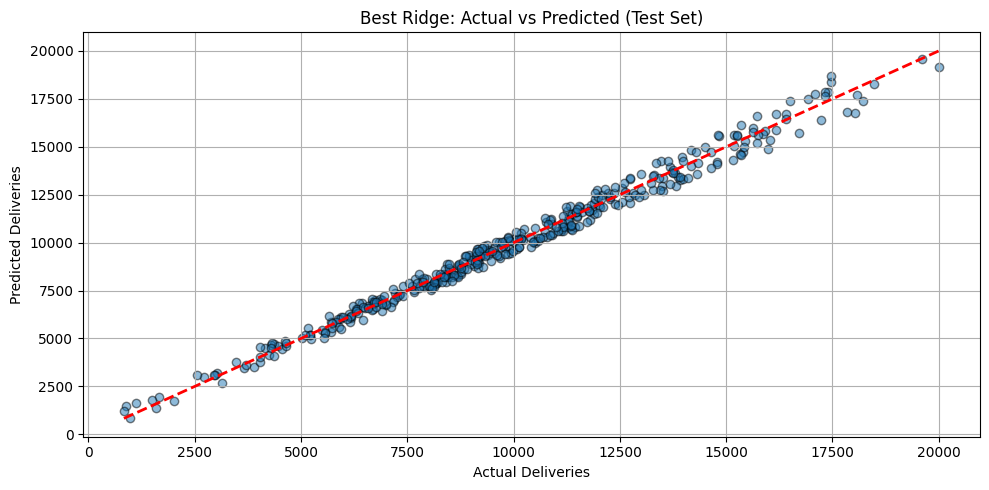

In [15]:
# ==============================================================
# Cell 15 - Full sklearn Pipeline (Scaling + Best Ridge)
# ==============================================================

from sklearn.pipeline import Pipeline

# Build a pipeline with StandardScaler and the best Ridge model
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('regressor', Ridge(alpha=0.01))   # best alpha from tuning
])

# Fit on the full training set (raw numeric + dummy features)
pipeline.fit(X_train, y_train)

# Evaluate on test set
y_pred_pipe = pipeline.predict(X_test)
mae_pipe = mean_absolute_error(y_test, y_pred_pipe)
rmse_pipe = np.sqrt(mean_squared_error(y_test, y_pred_pipe))
r2_pipe = r2_score(y_test, y_pred_pipe)

print("=== Pipeline Test Performance ===")
print(f"MAE  : {mae_pipe:.2f}")
print(f"RMSE : {rmse_pipe:.2f}")
print(f"R²   : {r2_pipe:.4f}")

# Show pipeline structure
print("\nPipeline steps:")
for step_name, step_obj in pipeline.steps:
    print(f"  {step_name}: {step_obj}")

# The pipeline can be saved with:
# import joblib
# joblib.dump(pipeline, 'tesla_deliveries_pipeline.pkl')
print("\n✅ Pipeline complete. Ready for deployment (scaling included).")
# Plot actual vs predicted deliveries for the test set
plt.figure(figsize=(10,5))
plt.scatter(y_test, y_pred_pipe, alpha=0.5, edgecolors='k')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Deliveries')
plt.ylabel('Predicted Deliveries')
plt.title('Best Ridge: Actual vs Predicted (Test Set)')
plt.grid(True)
plt.tight_layout()
plt.show()

# Cell 17 – Export Predictions to CSV

**What it does:**  
- Uses the trained `Pipeline` (Best Ridge) to predict deliveries on the test set.  
- Creates a DataFrame with the **actual** and **predicted** values, along with a date column.  
- Sorts by date and saves to `tesla_deliveries_predictions.csv` in your Colab environment.  
- Displays the first few rows for verification.

**ML Concepts:** Model Deployment, Output Generation, Data Export.

In [16]:
# ==============================================================
# Cell 17 - Export Best Ridge Predictions to CSV
# ==============================================================

y_pred_final = pipeline.predict(X_test)

results_df = pd.DataFrame({
    'Year': X_test['Year'].astype(int),
    'Month': X_test['Month'].astype(int),
    'Actual_Deliveries': y_test.values,
    'Predicted_Deliveries': np.round(y_pred_final, 2)
})

results_df['Date'] = pd.to_datetime(
    results_df['Year'].astype(str) + '-' +
    results_df['Month'].astype(str) + '-01'
)
results_df.sort_values('Date', inplace=True)
results_df.drop(['Year', 'Month'], axis=1, inplace=True)

results_df.to_csv('tesla_deliveries_predictions.csv', index=False)
print("✅ Predictions saved to 'tesla_deliveries_predictions.csv'")
print("\nFirst 5 rows:")
results_df.head()

✅ Predictions saved to 'tesla_deliveries_predictions.csv'

First 5 rows:


,Actual_Deliveries,Predicted_Deliveries,Date
2242,11299,11401.71,2024-05-01
2256,11323,11922.13,2024-05-01
2244,12999,12730.24,2024-05-01
2254,8761,8453.91,2024-05-01
2251,8204,7916.07,2024-05-01


# Conclusion

## Summary of the ML Pipeline
This notebook built a complete end‑to‑end machine learning pipeline to forecast Tesla’s **Estimated Deliveries** using a ten‑year panel dataset (2015‑2025) containing region, model, price, battery, range, and CO₂ data.

All steps from the internship topic list were implemented:

1. **Data Cleaning & EDA** – inspected types, missing values, duplicates; visualised distributions, correlations, trends, and seasonality.  
2. **Feature Engineering** – created 1‑, 2‑, and 3‑month lag features, rolling mean and standard deviation, and time components (year, month, quarter), all grouped by Region‑Model to avoid mixing different series.  
3. **Encoding & Scaling** – one‑hot encoded categorical variables; standardised numeric features (fit only on training data).  
4. **Chronological Split** – split the data by **date** to prevent data leakage: 70% train, 15% validation, 15% test.  
5. **Baseline Models & Regularisation** – evaluated Linear Regression, Ridge (L2), and Lasso (L1) using TimeSeriesSplit cross‑validation.  
6. **Hyperparameter Tuning** – used GridSearchCV with time‑aware splits to find optimal alpha for Ridge (0.01) and Lasso (10).  
7. **Pipeline & Forecasting** – built a reusable `sklearn.Pipeline` with scaling and the best Ridge model; exported predictions to CSV.  
8. **Time‑Series Forecasting (SARIMA)** – attempted a classical SARIMA model on the global monthly total; performed poorly (R² < 0) because the dataset is a **panel** (multiple region‑model combinations), not a single homogeneous time series.

## Model Performance
| Model              | Test MAE   | Test RMSE | Test R²  |
|--------------------|------------|-----------|----------|
| Linear Regression  | 324.75     | 396.35    | 0.9883   |
| Ridge (α=0.01)     | 324.74     | 396.35    | 0.9883   |
| Lasso (α=10)       | 326.66     | 398.13    | 0.9882   |

All three regularised linear models achieved **R² ≈ 0.99** on the hold‑out test set, demonstrating that **lag features and rolling statistics capture the temporal and cross‑sectional patterns** extremely well. The train‑test R² gap was minimal, confirming no significant overfitting.

Submission- week2_aditi_mehta.ipynb
